In [6]:
# Import libraries
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lasio

In [7]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'

In [8]:
# Check the wells and logs available in the LAS files
well_names = ["BLT-01", "JUT-01", "EVD-01", "PKP-01"]

for well in well_names:
    las = lasio.read(RAW / f"{well}.las")
    df_las = las.df()
    df_las.index.name = "MD"    # the index is the depth column
    df_las = df_las.reset_index()

    # Replace null values (-999.25) with NaN
    df_las = df_las.replace(-999.25, float("nan"))

    print(f"\nWell Name: {well}")
    print("LAS DataFrame shape:", df_las.shape)
    print("Columns:", list(df_las.columns))
    df_las.head(8)


Well Name: BLT-01
LAS DataFrame shape: (27875, 20)
Columns: ['MD', 'BITSIZE', 'CALI', 'CASING_FLAG-(S)GR_NPHI_DTC', 'DRHO', 'DTC', 'DTS', 'DTST', 'GR', 'GRKT', 'GRTO', 'NPHI', 'PE', 'POTA', 'RD', 'RHOB', 'RM', 'RS', 'THOR', 'URAN']

Well Name: JUT-01
LAS DataFrame shape: (22427, 5)
Columns: ['MD', 'DEPT:2', 'GR', 'DT', 'RHOB']

Well Name: EVD-01
LAS DataFrame shape: (21569, 5)
Columns: ['MD', 'GR', 'DT', 'RHOB', 'DRHO']

Well Name: PKP-01
LAS DataFrame shape: (27508, 6)
Columns: ['MD', 'GR', 'DT', 'RHOB', 'DRHO', 'NPHI']


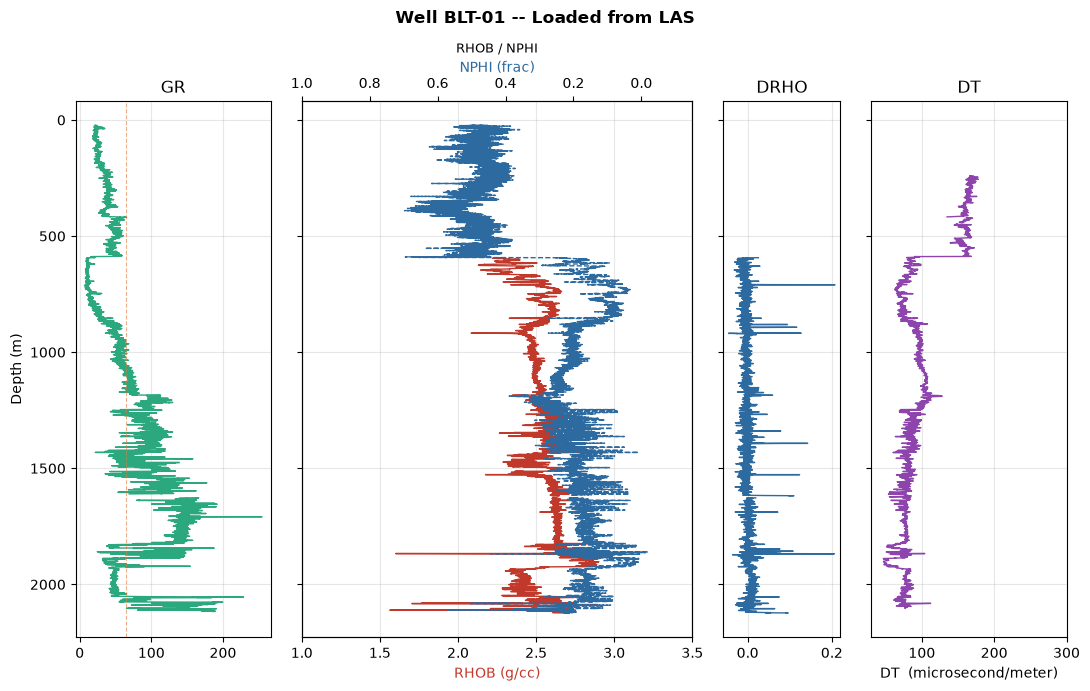

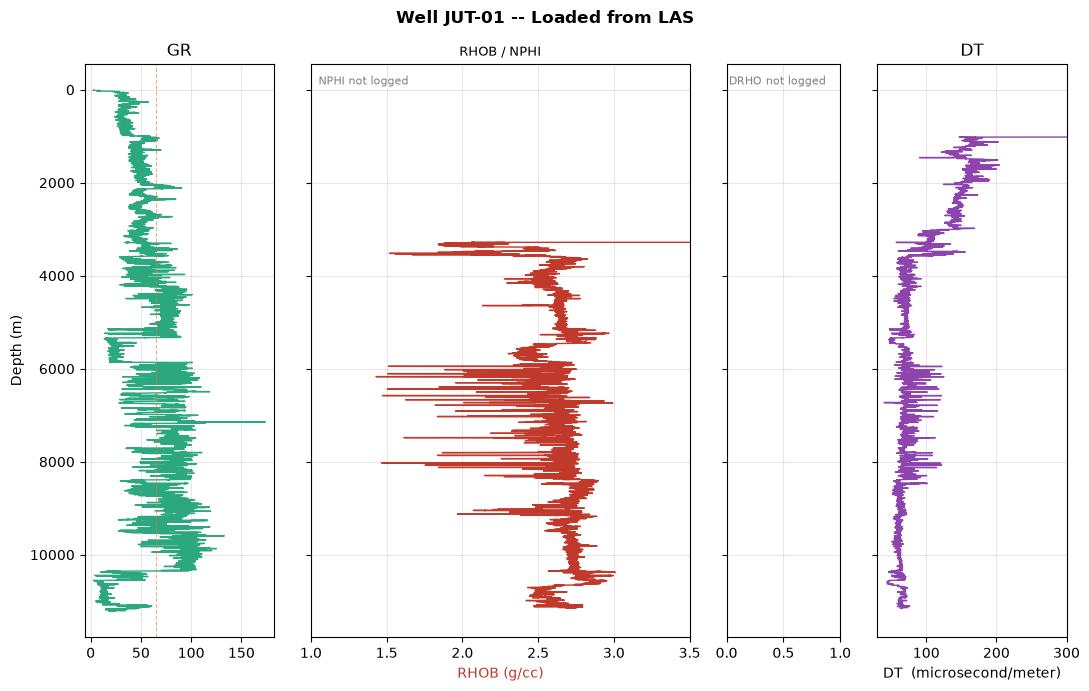

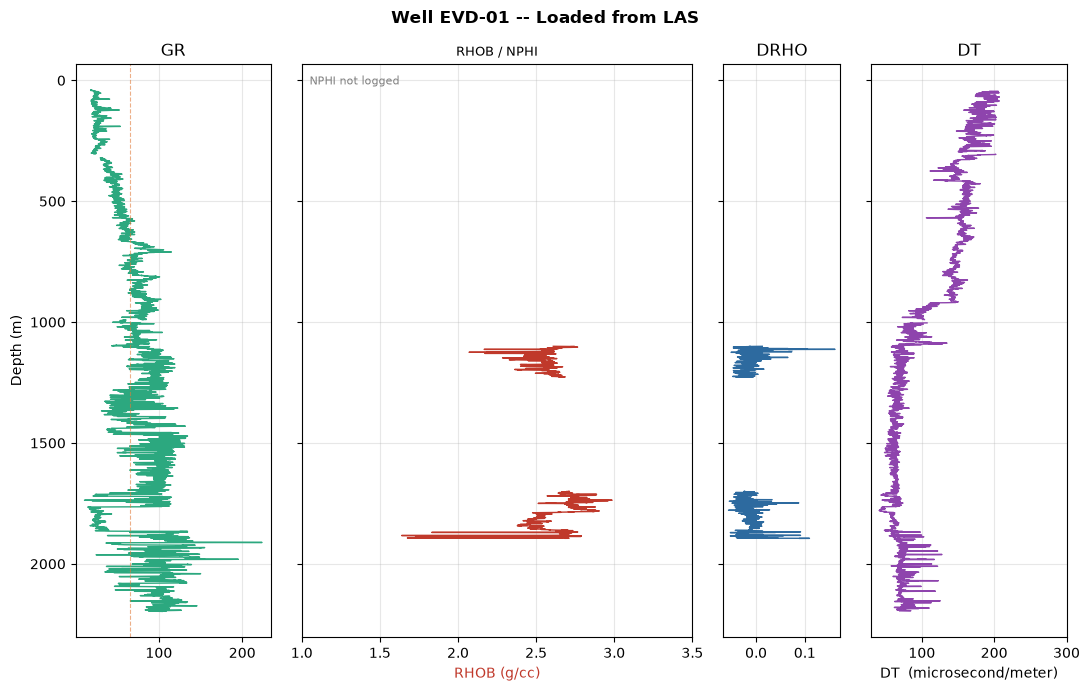

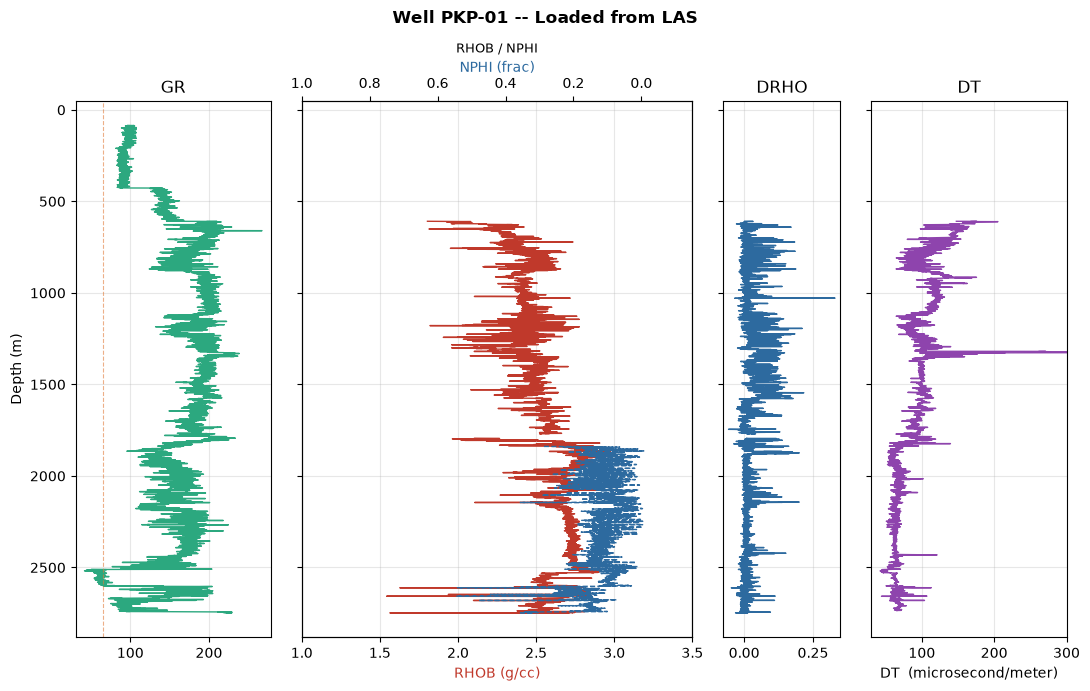

In [9]:
# GR, RHOB, NPHI, DRHO, DT/DTC logs plotted
for well in well_names:
    las = lasio.read(RAW / f"{well}.las")
    df_las = las.df()
    df_las.index.name = "MD"
    df_las = df_las.reset_index()

    df_las_clean = df_las.sort_values("MD")

    fig, axes = plt.subplots(1, 4, figsize=(11, 7), sharey=True, gridspec_kw={"width_ratios": [1, 2, 0.6, 1]})
    fig.suptitle(f"Well {well} -- Loaded from LAS", fontsize=12, fontweight="bold")

    axes[0].plot(df_las_clean["GR"], df_las_clean["MD"], color="#2ca87f", linewidth=1)
    axes[0].axvline(65, color="#e07b39", linestyle="--", linewidth=0.8, alpha=0.6)
    axes[0].set_label("GR (API)") 
    axes[0].set_title("GR") 
    axes[0].invert_yaxis() 
    axes[0].set_ylabel("Depth (m)") 

    ax2a = axes[1]
    ax2a.plot(df_las_clean["RHOB"], df_las_clean["MD"], color="#c0392b", linewidth=1, label="RHOB")
    ax2a.set_xlabel("RHOB (g/cc)", color="#c0392b")

    if "NPHI" in df_las_clean.columns:
        ax2b = ax2a.twiny()
        ax2b.plot(df_las_clean["NPHI"], df_las_clean["MD"], color="#2d6a9f", linewidth=1, linestyle="--", label="NPHI")
        ax2b.set_xlabel("NPHI (frac)", color="#2d6a9f")
    else:
        ax2a.text(0.02, 0.98, "NPHI not logged", transform=ax2a.transAxes, va="top", fontsize=8, color="gray")
    axes[1].set_title("RHOB / NPHI", fontsize=9) 
    ax2a.set_xlim(1.0, 3.5)
    ax2b.set_xlim(1.0, -0.15)

    if "DRHO" in df_las_clean.columns:
        axes[2].plot(df_las_clean["DRHO"], df_las_clean["MD"], color="#2d6a9f", linewidth=1)
        axes[2].set_label("DRHO  (g/cc)")
        axes[2].set_title("DRHO")
    else:
        axes[2].text(0.02, 0.98, "DRHO not logged", transform=axes[2].transAxes, va="top", fontsize=8, color="gray")

    dt_col = "DT" if "DT" in df_las_clean.columns else ("DTC" if "DTC" in df_las_clean.columns else None)

    axes[3].plot(df_las_clean[dt_col], df_las_clean["MD"], color="#8e44ad", linewidth=1)
    axes[3].set_xlabel("DT  (microsecond/meter)")
    axes[3].set_title("DT")
    axes[3].set_xlim(30, 300)

    for ax in axes: 
        ax.grid(True, alpha=0.3)

    plt.tight_layout() 
    plt.show()